# Réalisez une ACP - Le jeu de données mystère - Enoncé

# 1 Preliminary

## 1.1 Context

Ce TP est en lien avec l'activité [Réalisez une ACP](https://openclassrooms.com/fr/courses/4525281-realisez-une-analyse-exploratoire-de-donnees/5345201-tp-realisez-une-acp), de la partie 2 du cours  [Réalisez une analyse exploratoire de données](https://openclassrooms.com/fr/courses/4525281-realisez-une-analyse-exploratoire-de-donnees).

Nous allons travailler sur le *jeu de données mystère*.

Prenez le temps de bien **lire**, **comprendre** et **tester** le code ci dessous.

<br>

------------------------------

<br>

En cas de question, n'hésitez pas à nous adresser vos remarques ou suggestions via ce [lien](https://openclassrooms.zendesk.com/hc/fr/requests/new).

<br>

-------------------------

<br>

* version : 0.0.2
* last update:  2023-04-19

<br>

## 1.2 Imports

Nous allons importer nos librairies :

In [1]:
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

import seaborn as sns

## 1.3 Graphics and Options

On *charge* `seaborn` :

In [2]:
sns.set()

<link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/bootstrap@4.0.0/dist/css/bootstrap.min.css" integrity="sha384-Gn5384xqQ1aoWXA+058RXPxPg6fy4IWvTNh0E263XmFcJlSAwiGgFAW/dAiS6JXm" crossorigin="anonymous">
<script src="https://code.jquery.com/jquery-3.2.1.slim.min.js" integrity="sha384-KJ3o2DKtIkvYIK3UENzmM7KCkRr/rE9/Qpg6aAZGJwFDMVNA/GpGFF93hXpG5KkN" crossorigin="anonymous"></script>
<script src="https://cdn.jsdelivr.net/npm/popper.js@1.12.9/dist/umd/popper.min.js" integrity="sha384-ApNbgh9B+Y1QKtv3Rn7W3mgPxhU9K/ScQsAP7hUibX39j7fakFPskvXusvfa0b4Q" crossorigin="anonymous"></script>
<script src="https://cdn.jsdelivr.net/npm/bootstrap@4.0.0/dist/js/bootstrap.min.js" integrity="sha384-JZR6Spejh4U02d8jOt6vLEHfe/JQGiRRSQQxSfFWpi1MquVdAyjUar5+76PVCmYl" crossorigin="anonymous"></script>

## 1.4 Data

Nous allons maintenant charger les données. Pour ce faire vous pouvez les retrouver sur cette [page du cours](https://openclassrooms.com/fr/courses/4525281-realisez-une-analyse-exploratoire-de-donnees/5148885-telechargez-les-jeux-de-donnees-analyses-dans-ce-cours).

<br>

------------------------


<br>


Si vous utlisez Google Colab et que vous ne savez pas comment importer un fichier .csv, voici une [vidéo](https://youtu.be/6HFlwqK3oeo?t=171) à regarder à partir de 2:53

<br>

-------------------------------------

<br>


Importons notre fichier :

In [3]:
df = pd.read_csv("mystery.csv", decimal=".")
df.head()

,0,1,2
0,-7.988979,15.633928,-5.726221
1,0.108386,-3.456144,22.272791
2,1.565447,10.915797,29.040207
3,0.765086,35.831929,20.892023
4,-8.880745,20.989331,8.337199


## 1.5 Functions

Nous allons copier - coller les fonctions de notre précédent notebook.

Ces fonctions sont assez complexes. Je ne vous demande pas de les comprendre de A à Z. Essayez juste de les lire à la volée pour voir si vous les comprenez.

Si vous ne comprenez pas tout, encore une fois, cela n'est pas grave.


Pour le graphe des correlations :

In [4]:
def correlation_graph(pca,
                      x_y,
                      features) :
    """Affiche le graphe des correlations

    Positional arguments :
    -----------------------------------
    pca : sklearn.decomposition.PCA : notre objet PCA qui a été fit
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2
    features : list ou tuple : la liste des features (ie des dimensions) à représenter
    """

    # Extrait x et y
    x,y=x_y

    # Taille de l'image (en inches)
    fig, ax = plt.subplots(figsize=(10, 9))

    # Pour chaque composante :
    for i in range(0, pca.components_.shape[1]):

        # Les flèches
        ax.arrow(0,0,
                pca.components_[x, i],
                pca.components_[y, i],
                head_width=0.07,
                head_length=0.07,
                width=0.02, )

        # Les labels
        plt.text(pca.components_[x, i] + 0.05,
                pca.components_[y, i] + 0.05,
                features[i])

    # Affichage des lignes horizontales et verticales
    plt.plot([-1, 1], [0, 0], color='grey', ls='--')
    plt.plot([0, 0], [-1, 1], color='grey', ls='--')

    # Nom des axes, avec le pourcentage d'inertie expliqué
    plt.xlabel('F{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)))
    plt.ylabel('F{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)))

    # J'ai copié collé le code sans le lire
    plt.title("Cercle des corrélations (F{} et F{})".format(x+1, y+1))

    # Le cercle
    an = np.linspace(0, 2 * np.pi, 100)
    plt.plot(np.cos(an), np.sin(an))  # Add a unit circle for scale

    # Axes et display
    plt.axis('equal')
    plt.show(block=False)

Pour les plans factoriels :

In [5]:
def display_factorial_planes(   X_projected,
                                x_y,
                                pca=None,
                                labels = None,
                                clusters=None,
                                alpha=1,
                                figsize=[10,8],
                                marker="." ):
    """
    Affiche la projection des individus

    Positional arguments :
    -------------------------------------
    X_projected : np.array, pd.DataFrame, list of list : la matrice des points projetés
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2

    Optional arguments :
    -------------------------------------
    pca : sklearn.decomposition.PCA : un objet PCA qui a été fit, cela nous permettra d'afficher la variance de chaque composante, default = None
    labels : list ou tuple : les labels des individus à projeter, default = None
    clusters : list ou tuple : la liste des clusters auquel appartient chaque individu, default = None
    alpha : float in [0,1] : paramètre de transparence, 0=100% transparent, 1=0% transparent, default = 1
    figsize : list ou tuple : couple width, height qui définit la taille de la figure en inches, default = [10,8]
    marker : str : le type de marker utilisé pour représenter les individus, points croix etc etc, default = "."
    """

    # Transforme X_projected en np.array
    X_ = np.array(X_projected)

    # On définit la forme de la figure si elle n'a pas été donnée
    if not figsize:
        figsize = (7,6)

    # On gère les labels
    if  labels is None :
        labels = []
    try :
        len(labels)
    except Exception as e :
        raise e

    # On vérifie la variable axis
    if not len(x_y) ==2 :
        raise AttributeError("2 axes sont demandées")
    if max(x_y )>= X_.shape[1] :
        raise AttributeError("la variable axis n'est pas bonne")

    # on définit x et y
    x, y = x_y

    # Initialisation de la figure
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # On vérifie s'il y a des clusters ou non
    c = None if clusters is None else clusters

    # Les points
    plt.scatter(   X_[:, x], X_[:, y], alpha=alpha,
                         c=c, cmap="Set1", marker=marker)
    sns.scatterplot(data=None, x=X_[:, x], y=X_[:, y], hue=c)

    # Si la variable pca a été fournie, on peut calculer le % de variance de chaque axe
    if pca :
        v1 = str(round(100*pca.explained_variance_ratio_[x]))  + " %"
        v2 = str(round(100*pca.explained_variance_ratio_[y]))  + " %"
    else :
        v1=v2= ''

    # Nom des axes, avec le pourcentage d'inertie expliqué
    ax.set_xlabel(f'F{x+1} {v1}')
    ax.set_ylabel(f'F{y+1} {v2}')

    # Valeur x max et y max
    x_max = np.abs(X_[:, x]).max() *1.1
    y_max = np.abs(X_[:, y]).max() *1.1

    # On borne x et y
    ax.set_xlim(left=-x_max, right=x_max)
    ax.set_ylim(bottom= -y_max, top=y_max)

    # Affichage des lignes horizontales et verticales
    plt.plot([-x_max, x_max], [0, 0], color='grey', alpha=0.8)
    plt.plot([0,0], [-y_max, y_max], color='grey', alpha=0.8)

    # Affichage des labels des points
    if len(labels) :
        # j'ai copié collé la fonction sans la lire
        for i,(_x,_y) in enumerate(X_[:,[x,y]]):
            plt.text(_x, _y+0.05, labels[i], fontsize='14', ha='center',va='center')

    # Titre et display
    plt.title(f"Projection des individus (sur F{x+1} et F{y+1})")
    plt.show()



Si vous avez vu des choses bizarres dans le code, pas de soucis, supprimez les lignes en question !

# 2 Data Preparation

Avant de nous jeter dans le grand bain, nous allons devoir étudier et préparer un peu le terrain.

## 2.1 Quick tour

Tout d'abord faisons un rapide tour de nos données. Commencons par les afficher :

In [6]:
df.head()

,0,1,2
0,-7.988979,15.633928,-5.726221
1,0.108386,-3.456144,22.272791
2,1.565447,10.915797,29.040207
3,0.765086,35.831929,20.892023
4,-8.880745,20.989331,8.337199


In [7]:
df.tail()

,0,1,2
4995,-0.724429,19.077317,-0.002715
4996,-1.941668,-3.481421,22.924661
4997,-4.305507,-5.330243,5.650440
4998,-7.067287,9.422035,23.186741
4999,5.793738,-12.591809,18.570849


Quelle est la dimension de notre dataframe?

In [8]:
df.shape

(5000, 3)

La méthode `info` nous donne des indications globales :

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       5000 non-null   float64
 1   1       5000 non-null   float64
 2   2       5000 non-null   float64
dtypes: float64(3)
memory usage: 117.3 KB


Quel est le % de valeurs manquantes par colonne ?

In [10]:
df.isna().mean()

0    0.0
1    0.0
2    0.0
dtype: float64

Y a-t-il des lignes en double ?

In [11]:
df.duplicated().sum()

np.int64(190)

Combien y a-t-il de valeurs différentes par colonne ?

In [12]:
df.nunique()

0    4810
1    4810
2    4810
dtype: int64

Enfin la methode `describe` nous donne une idée de la dispertion globale de nos données :

In [13]:
df.describe()

,0,1,2
count,5000.000000,5000.000000,5000.000000
mean,-1.435869,13.987612,14.640661
std,5.206094,17.666334,9.329521
min,-11.222926,-29.753165,-8.943011
25%,-5.886956,-1.595890,8.535664
50%,-1.351116,16.628227,15.998955
75%,3.143237,27.312951,21.854507
max,8.485872,44.376445,30.373069


Le dataframe est assez simple, pas de nettoyage à faire. Tant mieux!

# 3 About PCA

## 3.1 Scaling

Nous allons effectuer notre scaling. Attention toutefois, réduire n'est ici pas nécessaire car les variables sont exprimées dans la même unité.

On se contente juste de centrer les données, ce qui est obligatoire pour une ACP.

Pour ce faire, on peut utiliser l'argument `with_std=False` :

In [14]:
scaler = StandardScaler(with_std=False)
scaler

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",False


On fit :

In [15]:
X = df.values

scaler.fit(X)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",False


On transforme :

In [16]:
X_scaled = scaler.transform(X)
X_scaled[:5]

array([[ -6.55311011,   1.64631658, -20.36688189],
       [  1.54425529, -17.44375528,   7.63213002],
       [  3.00131612,  -3.07181447,  14.39954624],
       [  2.20095531,  21.84431694,   6.25136213],
       [ -7.44487575,   7.00171974,  -6.30346199]])

In [17]:
idx = ["mean", "std"]

pd.DataFrame(X_scaled).describe().round(2).loc[idx, :]

,0,1,2
mean,-0.00,0.00,0.00
std,5.21,17.67,9.33


## 3.2 PCA

Nous allons travailler sur les 3 composantes :

In [18]:
n_components = 3

On instancie notre ACP :

In [19]:
pca = PCA(n_components=n_components)

On l'entraine :

In [20]:
pca.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",3
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

## 3.3 Explained variance & scree plot

Intéressons nous maintenant à la variance *captée* par chaque nouvelle composante. Grace à `scikit-learn` on peut utiliser l'attribut `explained_variance_ratio_` :

In [21]:
pca.explained_variance_ratio_

array([0.74965329, 0.20442347, 0.04592324])

Ici la 1ère composante *capte* 75% de la variance de nos données initiales, la 2ème 20% etc etc.

Enregistrons cela dans une variable :

In [28]:
scree = (pca.explained_variance_ratio_*100).round(2)
scree

array([74.97, 20.44,  4.59])

Les 2 premières composantes *captent* - à elles seules -  `75+20 = 95%` de la variance!!!

Dans le jargon, cela s'appelle une *somme cumulée*. Et pour faire une somme cumulée `numpy`dispose de la fonction `cumsum` :

In [29]:
scree_cum = scree.cumsum().round()
scree_cum

array([ 75.,  95., 100.])

Définisions ensuite une variable avec la liste de nos composantes :

In [30]:
x_list = range(1, n_components+1)
list(x_list)

[1, 2, 3]

On peut enfin l'afficher de façon graphique :

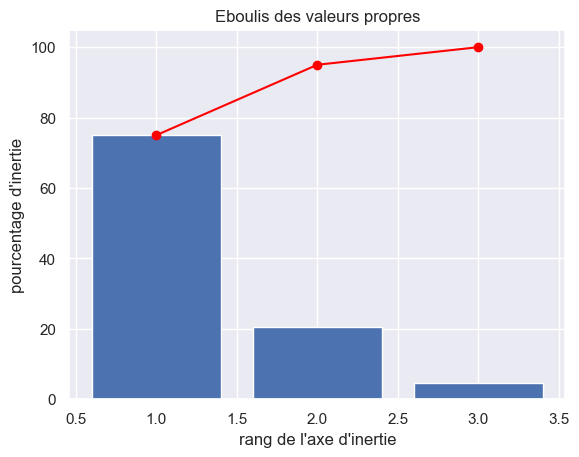

In [31]:
plt.bar(x_list, scree)
plt.plot(x_list, scree_cum,c="red",marker='o')
plt.xlabel("rang de l'axe d'inertie")
plt.ylabel("pourcentage d'inertie")
plt.title("Eboulis des valeurs propres")
plt.show(block=False)

On a en bleu la variance de chaque nouvelle composante, et en rouge la variance cumulée.

On voit ici que près de 95% de la variance est comprise dans les 2 premières composantes. En clair, la 3e composante n'est pas très *utile*...

## 3.4 Components

Intéressons nous maintenant à nos fameuses composantes. Nous avons dit dans le cours que c'est bien par un calcul que l'on obtient ces composantes.

La formule de ce calcul nous est donnée par l'attribut `components_`. Cette variable est généralement nommée `pcs` :

In [32]:
pcs = pca.components_
pcs

array([[-0.15580956,  0.98750579,  0.02357312],
       [ 0.06045988, -0.01428585,  0.99806839],
       [ 0.98593508,  0.15693382, -0.05747861]])

Affichons la même chose mais version `pandas` :

In [33]:
pcs = pd.DataFrame(pcs)
pcs

,0,1,2
0,-0.155810,0.987506,0.023573
1,0.060460,-0.014286,0.998068
2,0.985935,0.156934,-0.057479


Intéressant... Mais pas encore très clair...
Continuons le travail :

In [34]:
pcs.columns = df.columns
pcs.index = [f"F{i}" for i in x_list]
pcs.round(2)

,0,1,2
F1,-0.16,0.99,0.02
F2,0.06,-0.01,1.00
F3,0.99,0.16,-0.06


De mieux en mieux !  

-- **ATTENTION** -- : Nous avons arrondi les résultats pour simplifier l'analyse :)



Alors, comment calcule t-on la première composante `F1` ?

et bien c'est assez simple :

`F1 = (0.16 * x) + (-0.99 * y) + (0.02 * z)`

et F2 ?

`F2 = (-0.06 * x) + (-0.01 * y) + (-1.0 * z)`

**Eureka !**



Dans certains cas, on voudra afficher ce dataframe comme cela :

In [40]:
pcs.T

,F1,F2,F3
0,-0.155810,0.060460,0.985935
1,0.987506,-0.014286,0.156934
2,0.023573,0.998068,-0.057479


Et pour une représentation plus *visuelle*, comme cela :

<Axes: >

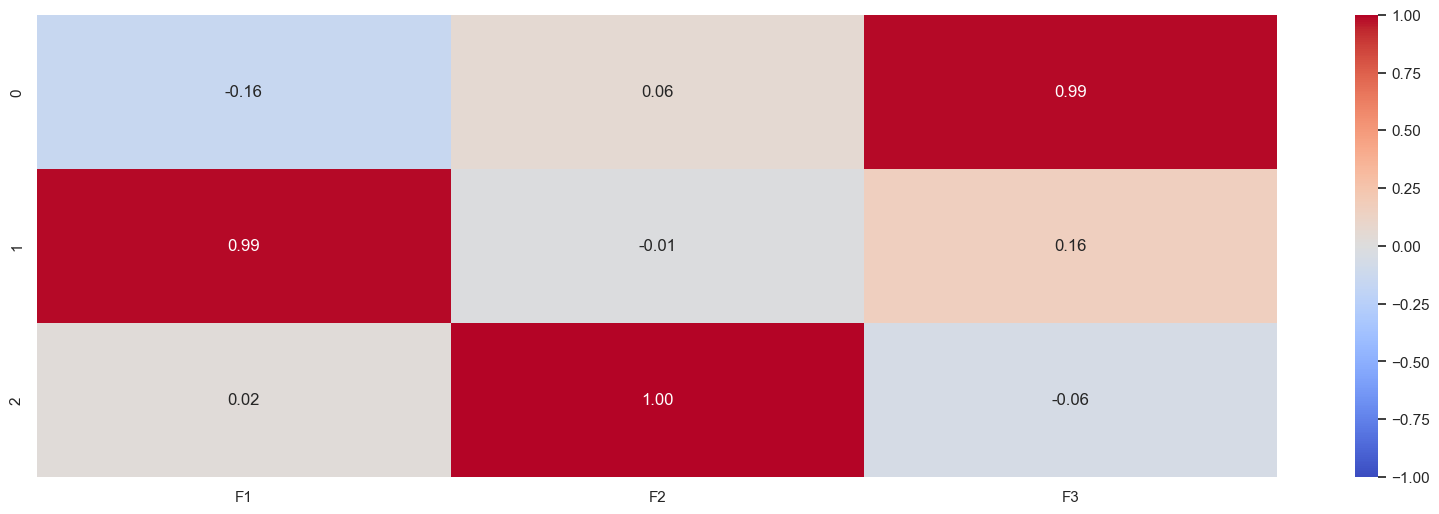

In [ ]:
fig, ax = plt.subplots(figsize=(20, 6))
sns.heatmap(pcs.T, vmin=-1, vmax=1, annot=True, cmap="coolwarm", fmt="0.2f")

A ce stade, on sait déja que :  
* `F1+F2 =95%` de la variance.
* `F1 = -y + 'un peu' de x` et `F2 = z`

## 3.5 Correlation graph

Pour la partie graphique, nous allons utiliser les fonctions vues dans la section 1.5.



Définissons nos axes x et y. Nous allons utiliser les 2 premières composantes. Comme - en code - on commence à compter à partir de 0, cela nous donne :

In [44]:
x, y = 0,1
x_y = (0,1)
features = df.columns

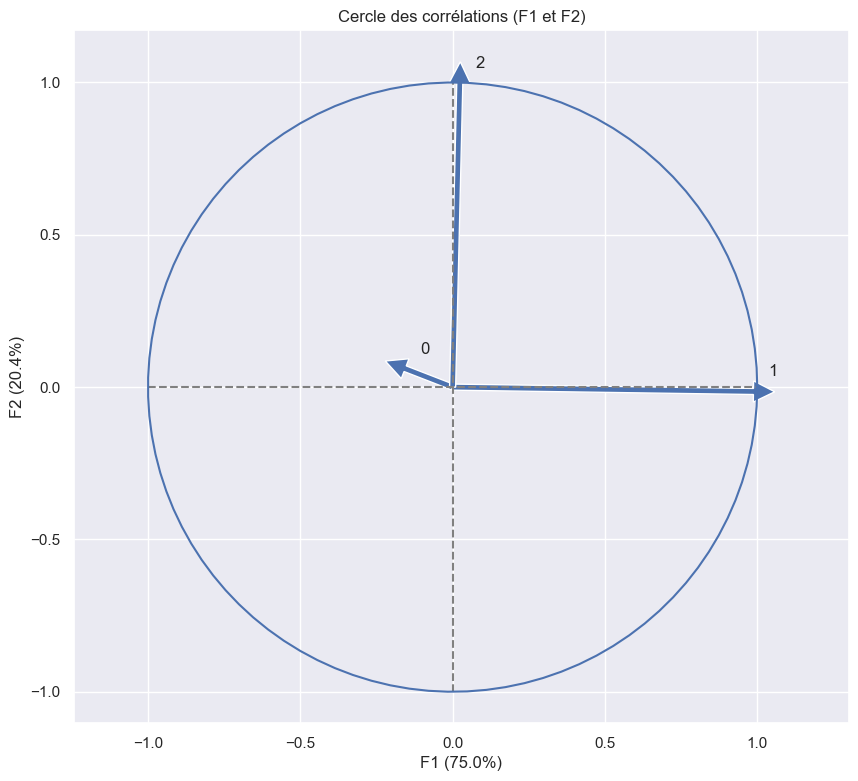

In [45]:
correlation_graph(pca, x_y, features)

Conclusion : F1 est principalement composée de -y et F2 de -z.

## 3.6 Projection

Travaillons maintenant sur la projection de nos dimensions. Tout d'abord calculons les coordonnées de nos individus dans le nouvel espace :

In [46]:
X_proj = pca.transform(X_scaled)
X_proj[:5]

array([[  2.16667348, -20.74726035,  -5.03191836],
       [-17.28650602,   7.95995203,  -1.65366397],
       [ -3.16162615,  14.59707465,   1.64936538],
       [ 21.37582371,   6.06029191,   5.23879165],
       [  7.92562936,  -6.84142795,  -5.8790433 ]])

On rappelle que :

In [47]:
x, y

(0, 1)

In [48]:
x_y = x, y
x_y

(0, 1)

Essayons avec F1 et F2 :

C:\Users\MonCompte\AppData\Local\Temp\ipykernel_6868\3444657718.py:58: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(   X_[:, x], X_[:, y], alpha=alpha,


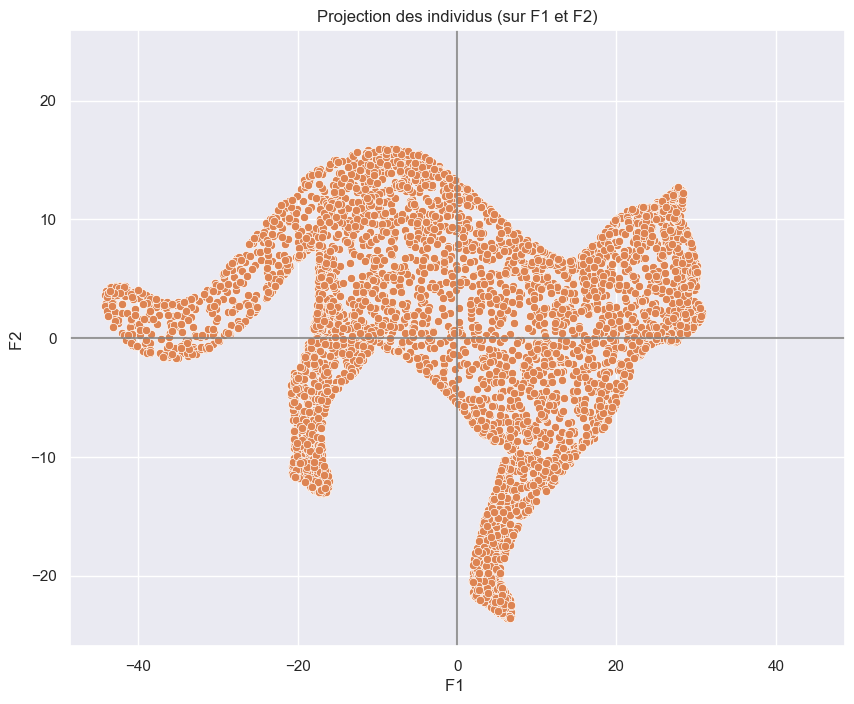

In [49]:
display_factorial_planes(X_proj, x_y)

Ohhhh ... Un chat !

Essayons avec F1 et F3 :

C:\Users\MonCompte\AppData\Local\Temp\ipykernel_6868\3444657718.py:58: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(   X_[:, x], X_[:, y], alpha=alpha,


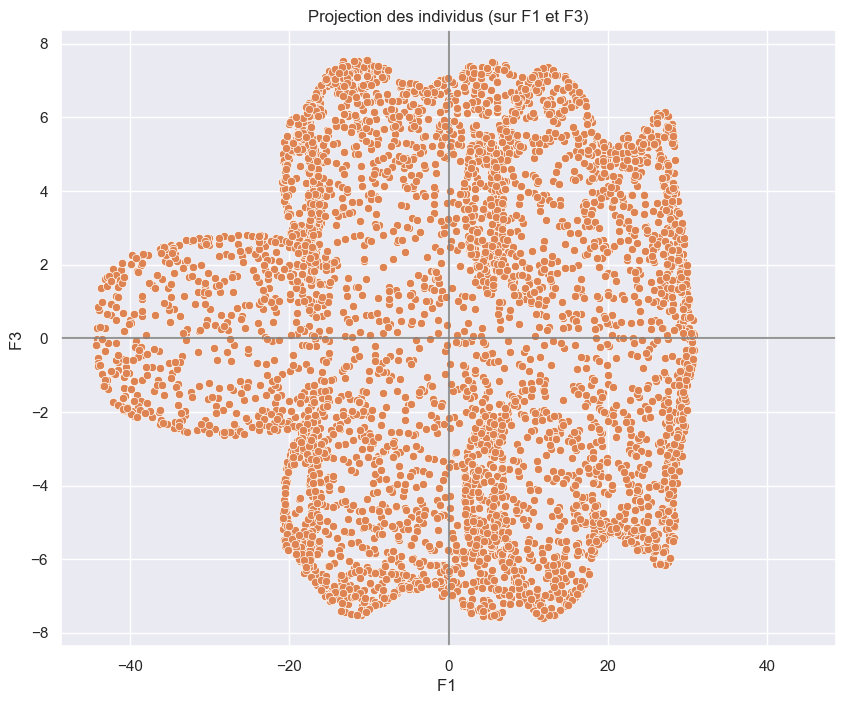

In [50]:
x_y = [0,2]

display_factorial_planes(X_proj, x_y)

Un chat vue de dessous ?

C:\Users\MonCompte\AppData\Local\Temp\ipykernel_6868\3444657718.py:58: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(   X_[:, x], X_[:, y], alpha=alpha,


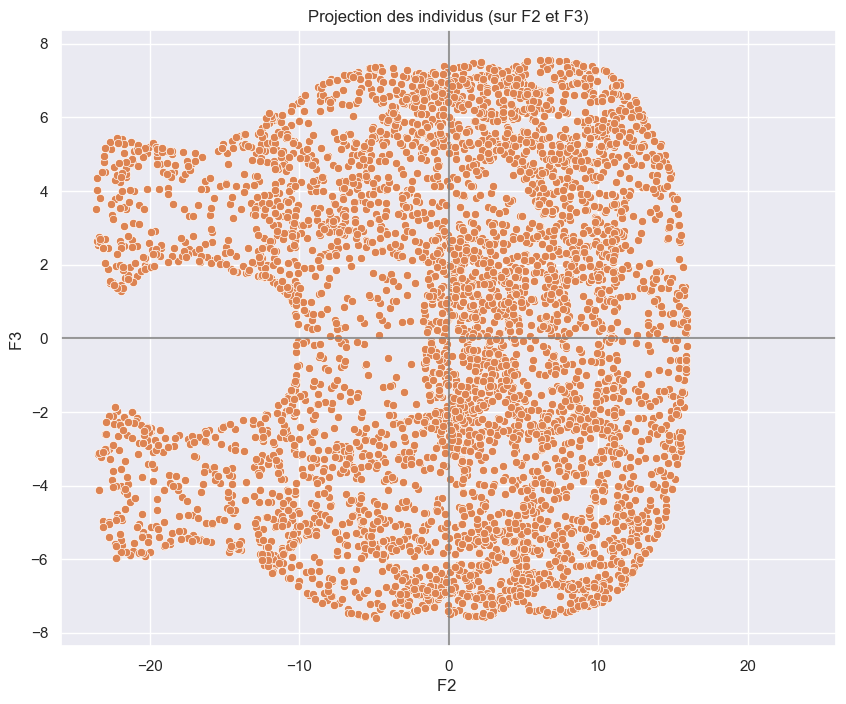

In [51]:
x_y = [1,2]

display_factorial_planes(X_proj, x_y)

Un chat vue de derrière ?

## 3.7 Bonus

Je vous laisse avec un petit bonus. Nous allons utiliser la librairie `plotly` pour faire un affichage en 3 dimensions :

In [58]:
import plotly.express as px 

# On passe les noms des colonnes sous forme de chaînes de caractères
fig = px.scatter_3d(df, x='0', y='1', z='2', opacity=0.3)
fig.show()

Passez votre souris sur l'image, vous pourrez zoomer, dézoomer, décaller les axes etc etc.

Magique non ?


Pour en savoir plus, c'est par [ici](https://plotly.com/python/).

# 4 Conclusion

Vous êtes arrivé au bout de ce travail, Bravo!

Il ne reste plus qu'à vous entrainer sur d'autres jeux de données :)

En cas de questions, n'hésitez pas à nous adresser vos questions, remarques ou suggestions sur le [formulaire](https://openclassrooms.zendesk.com/hc/fr/requests/new) .

